# Hybrid ML Pipeline — Autoencoder + XGBoost + SHAP
### Phase 2 & 3 of Project Architecture

This notebook implements, in order:
1. Data loading & cleaning (CIC-IDS2017 sample)
2. Benign/malicious split (Autoencoder trains ONLY on benign baseline traffic)
3. **Model 1 — Autoencoder**: anomaly detection via reconstruction error
4. **Model 2 — XGBoost**: attack type categorization on malicious traffic subset
5. **SHAP Explainer**: top-3 driver features per anomaly, formatted as JSON

Update `DATA_PATH` in the next code cell to point at your CIC-IDS2017 CSV before running.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
import xgboost as xgb
import shap
import joblib
import json

## 1. Load & Sample Dataset
Sampling keeps training fast (per project time-saving guidance: 20k-50k rows).

In [2]:
# CONFIG
SAMPLE_SIZE = 40000

# CIC-IDS2017 dataset files
MONDAY_PATH = "../data/Monday-WorkingHours.pcap_ISCX.csv"
TUESDAY_PATH = "../data/Tuesday-WorkingHours.pcap_ISCX.csv"
DDOS_PATH = "../data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"
PORTSCAN_PATH = "../data/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv"

# Load the four datasets
monday = pd.read_csv(MONDAY_PATH, low_memory=False)
tuesday = pd.read_csv(TUESDAY_PATH, low_memory=False)
ddos = pd.read_csv(DDOS_PATH, low_memory=False)
portscan = pd.read_csv(PORTSCAN_PATH, low_memory=False)

print("Monday shape:", monday.shape)
print("Tuesday shape:", tuesday.shape)
print("DDoS shape:", ddos.shape)
print("PortScan shape:", portscan.shape)

# Combine datasets
df = pd.concat(
    [monday, tuesday, ddos, portscan],
    ignore_index=True
)

# Clean column names
df.columns = df.columns.str.strip()

print("Combined dataset shape:", df.shape)
print("\nLabel distribution:")
print(df["Label"].value_counts())

# Sample while preserving the proportion of each attack class
if len(df) > SAMPLE_SIZE:
    df = (
        df.groupby("Label", group_keys=False)
          .sample(frac=SAMPLE_SIZE / len(df), random_state=42)
          .reset_index(drop=True)
    )

print("\nFinal dataset shape:", df.shape)
print("\nFinal label distribution:")
print(df["Label"].value_counts())

Monday shape: (529918, 79)
Tuesday shape: (445909, 79)
DDoS shape: (225745, 79)
PortScan shape: (286467, 79)
Combined dataset shape: (1488039, 79)

Label distribution:
Label
BENIGN         1187247
PortScan        158930
DDoS            128027
FTP-Patator       7938
SSH-Patator       5897
Name: count, dtype: int64

Final dataset shape: (39999, 79)

Final label distribution:
Label
BENIGN         31914
PortScan        4272
DDoS            3441
FTP-Patator      213
SSH-Patator      159
Name: count, dtype: int64


## 2. Clean & Preprocess

In [3]:
# Drop identifier columns that aren't real features
drop_cols = [c for c in ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp'] if c in df.columns]
df = df.drop(columns=drop_cols)

# CIC-IDS2017 is known to contain inf/-inf values in a few flow-rate columns
df = df.replace([np.inf, -np.inf], np.nan).dropna()

X = df.drop(columns=['Label'])
y = df['Label']

X = X.select_dtypes(include=[np.number])

print(f"Feature count: {X.shape[1]}")
print(f"Rows after cleaning: {len(df)}")

Feature count: 78
Rows after cleaning: 39971


## 3. Split Benign vs Malicious
Per architecture: the Autoencoder is trained **exclusively on benign baseline traffic** to learn normal behavior.

In [4]:
benign_mask = y == 'BENIGN'

X_benign = X[benign_mask]
X_malicious = X[~benign_mask]
y_malicious = y[~benign_mask]

print(f"Benign samples: {len(X_benign)}")
print(f"Malicious samples: {len(X_malicious)}")
print(y_malicious.value_counts())

Benign samples: 31892
Malicious samples: 8079
Label
PortScan       4266
DDoS           3441
FTP-Patator     213
SSH-Patator     159
Name: count, dtype: int64


## 4. Scale Features
Scaler is fit ONLY on benign traffic — this defines what 'normal' looks like for the Autoencoder.

In [5]:
scaler = MinMaxScaler()

X_benign_scaled = scaler.fit_transform(X_benign)
X_malicious_scaled = scaler.transform(X_malicious)

joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

## 5. Model 1 — Autoencoder (Anomaly Detection)
TensorFlow/Keras autoencoder, 3-4 dense layers, trained strictly on benign traffic.

In [6]:
# Cell 6 — Autoencoder

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# Input dimension
input_dim = X_benign_scaled.shape[1]

# Define Autoencoder architecture
input_layer = Input(shape=(input_dim,))

encoder = Dense(32, activation="relu")(input_layer)
encoder = Dense(16, activation="relu")(encoder)
encoder = Dense(8, activation="relu")(encoder)

decoder = Dense(16, activation="relu")(encoder)
decoder = Dense(32, activation="relu")(decoder)
decoder = Dense(input_dim, activation="sigmoid")(decoder)

autoencoder = Model(input_layer, decoder)

# Compile model
autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

# Train only on benign traffic
history = autoencoder.fit(
    X_benign_scaled,
    X_benign_scaled,
    epochs=20,
    batch_size=256,
    validation_split=0.2,
    shuffle=True,
    verbose=1
)

# Save model
autoencoder.save("autoencoder_model.h5")

print("Autoencoder training complete.")

Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1046 - val_loss: 0.0182
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0175 - val_loss: 0.0176
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0170 - val_loss: 0.0169
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0156 - val_loss: 0.0131
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0085 - val_loss: 0.0061
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0053 - val_loss: 0.0047
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0043 - val_loss: 0.0041
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0037 - val_loss: 0.0033
Epoch 9/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0031 - val_loss: 0.0030
Epoch 10/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0028 - val_loss: 0.0027
Epoch 11/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0026 - val_loss: 0.0025
Epoch 12/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Autoencoder training complete.


## 6. Anomaly Threshold
High reconstruction error on unseen (malicious) traffic signals novel anomalies, per architecture.

In [7]:
# Cell 7 — Anomaly Threshold

# Reconstruct benign validation data
X_benign_reconstructed = autoencoder.predict(
    X_benign_scaled,
    verbose=0
)

# Calculate reconstruction error for each sample
benign_errors = np.mean(
    np.square(X_benign_scaled - X_benign_reconstructed),
    axis=1
)

# Set anomaly threshold at the 99th percentile of benign errors
threshold = np.percentile(benign_errors, 99)

print("Anomaly threshold:", threshold)

# Reconstruct malicious traffic
X_malicious_reconstructed = autoencoder.predict(
    X_malicious_scaled,
    verbose=0
)

# Calculate reconstruction error for malicious samples
malicious_errors = np.mean(
    np.square(X_malicious_scaled - X_malicious_reconstructed),
    axis=1
)

# Classify malicious samples as anomalies
malicious_predictions = malicious_errors > threshold

# Calculate detection rate
detection_rate = malicious_predictions.mean()

print("Malicious samples:", len(X_malicious_scaled))
print("Detected as anomalies:", malicious_predictions.sum())
print("Anomaly detection rate:", detection_rate)

Anomaly threshold: 0.019235283561922625
Malicious samples: 8079
Detected as anomalies: 1243
Anomaly detection rate: 0.15385567520732765


## 7. Model 2 — XGBoost Classifier (Attack Categorization)
Trained on the malicious traffic subset to instantly classify anomaly type (Port Scan, DDoS, Brute Force, etc.), per architecture.

In [8]:
# Cell 8 — XGBoost Attack Classification

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Encode attack labels
label_encoder = LabelEncoder()
y_malicious_encoded = label_encoder.fit_transform(y_malicious)

print("Attack classes:")
for i, label in enumerate(label_encoder.classes_):
    print(i, "=", label)

# Train XGBoost classifier
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42
)

xgb_model.fit(
    X_malicious_scaled,
    y_malicious_encoded
)

# Save model and label encoder
xgb_model.save_model("xgboost_classifier.json")
joblib.dump(label_encoder, "label_encoder.pkl")

print("\nXGBoost training complete.")
print("Model saved as: xgboost_classifier.json")
print("Label encoder saved as: label_encoder.pkl")

Attack classes:
0 = DDoS
1 = FTP-Patator
2 = PortScan
3 = SSH-Patator

XGBoost training complete.
Model saved as: xgboost_classifier.json
Label encoder saved as: label_encoder.pkl


## 8. SHAP Explainer Engine
Computes local SHAP values per anomaly and extracts the top 3 driver features, matching the structured JSON payload described in the architecture.

In [9]:
# Cell 9 — SHAP + End-to-End Hybrid Prediction

import shap
import json

# Create SHAP explainer for XGBoost
explainer = shap.TreeExplainer(xgb_model)

# Select a small sample for demonstration
sample_size = min(10, len(X_malicious_scaled))
X_demo = X_malicious_scaled[:sample_size]

# XGBoost predictions
predicted_encoded = xgb_model.predict(X_demo).astype(int)
predicted_labels = label_encoder.inverse_transform(predicted_encoded)

# Calculate Autoencoder reconstruction errors
X_demo_reconstructed = autoencoder.predict(
    X_demo,
    verbose=0
)

demo_errors = np.mean(
    np.square(X_demo - X_demo_reconstructed),
    axis=1
)

# Determine anomaly status
demo_anomalies = demo_errors > threshold

# Calculate SHAP values
shap_values = explainer.shap_values(X_demo)

# Handle SHAP output format
if isinstance(shap_values, list):
    shap_array = np.array(shap_values)
else:
    shap_array = np.array(shap_values)

print("End-to-end predictions:\n")

for i in range(sample_size):

    # Get SHAP values for predicted class
    if shap_array.ndim == 3:
        sample_shap = shap_array[i, :, predicted_encoded[i]]
    else:
        sample_shap = shap_array[i]

    # Get top 5 feature drivers
    top_indices = np.argsort(
        np.abs(sample_shap)
    )[-5:][::-1]

    top_drivers = []

    for idx in top_indices:
        top_drivers.append({
            "feature": X.columns[idx],
            "shap_value": float(sample_shap[idx])
        })

    result = {
        "anomaly_score": float(demo_errors[i]),
        "is_anomaly": bool(demo_anomalies[i]),
        "predicted_attack_type": str(predicted_labels[i]),
        "true_label": str(y_malicious.iloc[i]),
        "top_shap_drivers": top_drivers
    }

    print(json.dumps(result, indent=2))
    print("-" * 60)

End-to-end predictions:

{
  "anomaly_score": 0.00023929010474414862,
  "is_anomaly": false,
  "predicted_attack_type": "DDoS",
  "true_label": "DDoS",
  "top_shap_drivers": [
    {
      "feature": "Total Length of Fwd Packets",
      "shap_value": 2.087233304977417
    },
    {
      "feature": "act_data_pkt_fwd",
      "shap_value": 1.5223394632339478
    },
    {
      "feature": "Subflow Fwd Bytes",
      "shap_value": 0.31166061758995056
    },
    {
      "feature": "Init_Win_bytes_forward",
      "shap_value": 0.18415477871894836
    },
    {
      "feature": "Fwd Packets/s",
      "shap_value": 0.16030220687389374
    }
  ]
}
------------------------------------------------------------
{
  "anomaly_score": 0.10529653744997616,
  "is_anomaly": true,
  "predicted_attack_type": "DDoS",
  "true_label": "DDoS",
  "top_shap_drivers": [
    {
      "feature": "Total Length of Fwd Packets",
      "shap_value": 2.1140143871307373
    },
    {
      "feature": "act_data_pkt_fwd",
      

Training samples: 6463
Testing samples: 1616

XGBoost Evaluation Results
Accuracy : 0.9988
Precision: 0.9988
Recall   : 0.9988
F1 Score : 0.9988

Classification Report
              precision    recall  f1-score   support

        DDoS       1.00      1.00      1.00       688
 FTP-Patator       0.98      1.00      0.99        43
    PortScan       1.00      1.00      1.00       853
 SSH-Patator       0.97      1.00      0.98        32

    accuracy                           1.00      1616
   macro avg       0.99      1.00      0.99      1616
weighted avg       1.00      1.00      1.00      1616


Confusion Matrix
[[688   0   0   0]
 [  0  43   0   0]
 [  0   1 851   1]
 [  0   0   0  32]]


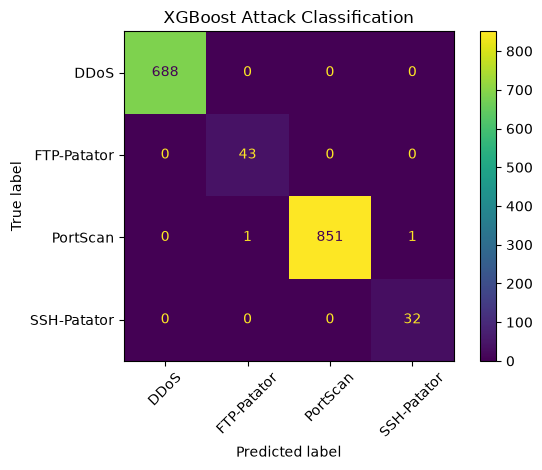


Final XGBoost model saved as:
xgboost_classifier.json


In [10]:
# Cell 10 — XGBoost Model Evaluation

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Create train/test split
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_malicious_scaled,
    y_malicious_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_malicious_encoded
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


# --------------------------------------------------
# 2. Train a fresh XGBoost model
# --------------------------------------------------

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)


# --------------------------------------------------
# 3. Make predictions on unseen test data
# --------------------------------------------------

y_pred = xgb_model.predict(X_test)


# --------------------------------------------------
# 4. Calculate performance metrics
# --------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)


# --------------------------------------------------
# 5. Print overall results
# --------------------------------------------------

print("\n==============================")
print("XGBoost Evaluation Results")
print("==============================")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")


# --------------------------------------------------
# 6. Detailed per-attack performance
# --------------------------------------------------

print("\n==============================")
print("Classification Report")
print("==============================")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)


# --------------------------------------------------
# 7. Confusion matrix
# --------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

print("\n==============================")
print("Confusion Matrix")
print("==============================")

print(cm)


# --------------------------------------------------
# 8. Display confusion matrix
# --------------------------------------------------

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    xticks_rotation=45
)

plt.title("XGBoost Attack Classification")
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 9. Save properly evaluated model
# --------------------------------------------------

xgb_model.save_model("xgboost_classifier.json")

print("\nFinal XGBoost model saved as:")
print("xgboost_classifier.json")

## 9. End-to-End Demo — Full Pipeline on One Sample
Autoencoder flags anomaly → XGBoost classifies attack type → SHAP explains why. This is the exact payload structure Phase 4 (Sentinel ingestion) will consume.


AUTOENCODER EVALUATION
Accuracy : 0.8210
Precision: 0.7958
Recall   : 0.1539
F1 Score : 0.2579

Classification Report
              precision    recall  f1-score   support

      BENIGN       0.82      0.99      0.90     31892
   MALICIOUS       0.80      0.15      0.26      8079

    accuracy                           0.82     39971
   macro avg       0.81      0.57      0.58     39971
weighted avg       0.82      0.82      0.77     39971


Confusion Matrix
[[31573   319]
 [ 6836  1243]]


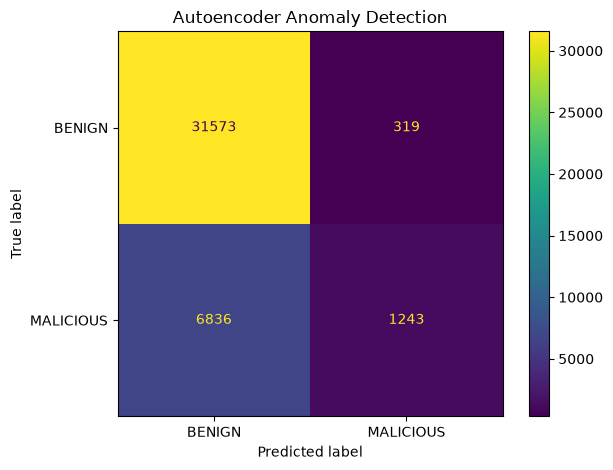


False Positive Rate: 0.0100
False Positive Rate (%): 1.00%

Detection Rate by Attack Type
Attack Type  Total Samples  Detected  Missed  Detection Rate (%)
       DDoS           3441      1242    2199           36.094159
FTP-Patator            213         0     213            0.000000
   PortScan           4266         1    4265            0.023441
SSH-Patator            159         0     159            0.000000


In [11]:
# Cell 11 — Autoencoder Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# --------------------------------------------------
# 1. Create true labels
# --------------------------------------------------

# BENIGN = 0
# MALICIOUS = 1

y_benign_binary = np.zeros(len(X_benign_scaled), dtype=int)
y_malicious_binary = np.ones(len(X_malicious_scaled), dtype=int)

y_true = np.concatenate([
    y_benign_binary,
    y_malicious_binary
])


# --------------------------------------------------
# 2. Combine reconstruction errors
# --------------------------------------------------

all_errors = np.concatenate([
    benign_errors,
    malicious_errors
])


# --------------------------------------------------
# 3. Convert reconstruction error into prediction
# --------------------------------------------------

# Error > threshold = anomaly/malicious

y_pred = (all_errors > threshold).astype(int)


# --------------------------------------------------
# 4. Calculate overall metrics
# --------------------------------------------------

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)


print("\n======================================")
print("AUTOENCODER EVALUATION")
print("======================================")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")


# --------------------------------------------------
# 5. Detailed classification report
# --------------------------------------------------

print("\n======================================")
print("Classification Report")
print("======================================")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["BENIGN", "MALICIOUS"],
        zero_division=0
    )
)


# --------------------------------------------------
# 6. Confusion matrix
# --------------------------------------------------

cm = confusion_matrix(y_true, y_pred)

print("\n======================================")
print("Confusion Matrix")
print("======================================")

print(cm)


# --------------------------------------------------
# 7. Display confusion matrix
# --------------------------------------------------

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["BENIGN", "MALICIOUS"]
)

disp.plot()

plt.title("Autoencoder Anomaly Detection")
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 8. Calculate false-positive rate
# --------------------------------------------------

true_benign = cm[0, 0]
false_positives = cm[0, 1]

false_positive_rate = (
    false_positives / (true_benign + false_positives)
)

print("\nFalse Positive Rate:", f"{false_positive_rate:.4f}")
print(
    "False Positive Rate (%):",
    f"{false_positive_rate * 100:.2f}%"
)


# --------------------------------------------------
# 9. Detection rate for each attack
# --------------------------------------------------

attack_results = []

for attack in label_encoder.classes_:

    attack_mask = (y_malicious == attack)

    attack_errors = malicious_errors[attack_mask]

    detected = np.sum(attack_errors > threshold)

    total = len(attack_errors)

    detection_rate = detected / total

    attack_results.append({
        "Attack Type": attack,
        "Total Samples": total,
        "Detected": detected,
        "Missed": total - detected,
        "Detection Rate (%)": detection_rate * 100
    })


attack_df = pd.DataFrame(attack_results)


print("\n======================================")
print("Detection Rate by Attack Type")
print("======================================")

print(
    attack_df.to_string(index=False)
)

In [12]:
# Cell 12 — Autoencoder Threshold Analysis

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

# --------------------------------------------------
# Test different threshold percentiles
# --------------------------------------------------

percentiles = [90, 92, 94, 95, 96, 97, 98, 99]

results = []

for percentile in percentiles:

    # Calculate threshold using BENIGN reconstruction errors
    test_threshold = np.percentile(
        benign_errors,
        percentile
    )

    # Predict anomaly
    predictions = (
        all_errors > test_threshold
    ).astype(int)

    # Metrics
    accuracy = accuracy_score(
        y_true,
        predictions
    )

    precision = precision_score(
        y_true,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        predictions,
        zero_division=0
    )

    # Confusion matrix
    test_cm = confusion_matrix(
        y_true,
        predictions
    )

    tn, fp, fn, tp = test_cm.ravel()

    # False positive rate
    fpr = fp / (fp + tn)

    results.append({
        "Percentile": percentile,
        "Threshold": test_threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "False Positive Rate": fpr
    })


# --------------------------------------------------
# Display results
# --------------------------------------------------

threshold_df = pd.DataFrame(results)

print("\n==============================================")
print("AUTOENCODER THRESHOLD ANALYSIS")
print("==============================================")

print(
    threshold_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# --------------------------------------------------
# Find best F1 threshold
# --------------------------------------------------

best_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print("\n==============================================")
print("BEST THRESHOLD BY F1 SCORE")
print("==============================================")

print(
    f"Percentile : {best_row['Percentile']}"
)

print(
    f"Threshold  : {best_row['Threshold']:.6f}"
)

print(
    f"Precision  : {best_row['Precision']:.4f}"
)

print(
    f"Recall     : {best_row['Recall']:.4f}"
)

print(
    f"F1 Score   : {best_row['F1']:.4f}"
)

print(
    f"False Positive Rate : "
    f"{best_row['False Positive Rate']:.4f}"
)


AUTOENCODER THRESHOLD ANALYSIS
 Percentile  Threshold  Accuracy  Precision  Recall     F1  False Positive Rate
         90     0.0034    0.7764     0.4221  0.2884 0.3427               0.1000
         92     0.0050    0.7858     0.4480  0.2563 0.3261               0.0800
         94     0.0086    0.7931     0.4737  0.2133 0.2941               0.0600
         95     0.0116    0.7977     0.4987  0.1964 0.2819               0.0500
         96     0.0128    0.8051     0.5505  0.1935 0.2863               0.0400
         97     0.0129    0.8130     0.6202  0.1935 0.2949               0.0300
         98     0.0141    0.8186     0.7039  0.1769 0.2827               0.0188
         99     0.0192    0.8210     0.7958  0.1539 0.2579               0.0100

BEST THRESHOLD BY F1 SCORE
Percentile : 90.0
Threshold  : 0.003387
Precision  : 0.4221
Recall     : 0.2884
F1 Score   : 0.3427
False Positive Rate : 0.1000


Benign training samples: 25513
Benign validation samples: 6379
Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0759 - val_loss: 0.0178
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0149 - val_loss: 0.0128
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0118 - val_loss: 0.0117
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0103 - val_loss: 0.0094
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0077 - val_loss: 0.0051
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0037 - val_loss: 0.0024
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0020 - val_loss: 0.0018
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0017 - val_loss: 0.0015
Epoch 9/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 10/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0012 - val_loss: 0.0011
Epoch 11/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0011 - val_lo

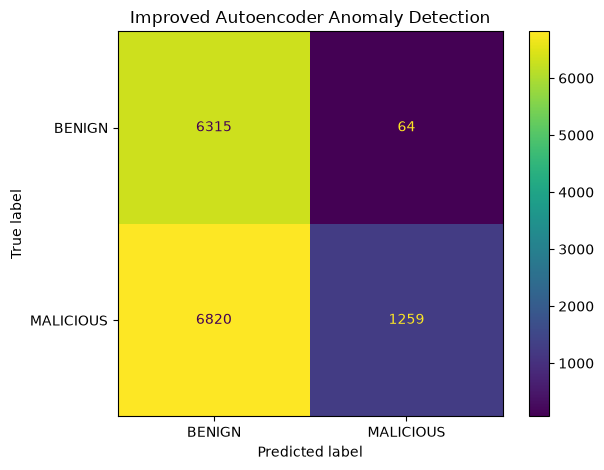


False Positive Rate: 0.0100
False Positive Rate (%): 1.00%

Detection Rate by Attack Type
Attack Type  Total Samples  Detected  Missed  Detection Rate (%)
       DDoS           3441      1242    2199           36.094159
FTP-Patator            213         0     213            0.000000
   PortScan           4266        17    4249            0.398500
SSH-Patator            159         0     159            0.000000

Improved Autoencoder saved as: improved_autoencoder_model.h5


In [13]:
# Cell 13 — Improved Autoencoder Training and Evaluation

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import numpy as np
import matplotlib.pyplot as plt


# ==================================================
# 1. Split BENIGN data
# ==================================================

X_benign_train, X_benign_val = train_test_split(
    X_benign_scaled,
    test_size=0.20,
    random_state=42
)

print("Benign training samples:", len(X_benign_train))
print("Benign validation samples:", len(X_benign_val))


# ==================================================
# 2. Build a fresh Autoencoder
# ==================================================

input_dim = X_benign_train.shape[1]

input_layer = Input(shape=(input_dim,))

encoder = Dense(64, activation="relu")(input_layer)
encoder = Dense(32, activation="relu")(encoder)
encoder = Dense(16, activation="relu")(encoder)

decoder = Dense(32, activation="relu")(encoder)
decoder = Dense(64, activation="relu")(decoder)

# Linear output is also tested here for reconstruction
decoder = Dense(input_dim, activation="sigmoid")(decoder)

improved_autoencoder = Model(
    input_layer,
    decoder
)

improved_autoencoder.compile(
    optimizer="adam",
    loss="mse"
)


# ==================================================
# 3. Train only on BENIGN training data
# ==================================================

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = improved_autoencoder.fit(
    X_benign_train,
    X_benign_train,
    epochs=50,
    batch_size=256,
    validation_data=(
        X_benign_val,
        X_benign_val
    ),
    shuffle=True,
    callbacks=[early_stopping],
    verbose=1
)


# ==================================================
# 4. Calculate reconstruction errors
# ==================================================

# Validation BENIGN reconstruction
benign_val_reconstructed = improved_autoencoder.predict(
    X_benign_val,
    verbose=0
)

benign_val_errors = np.mean(
    np.square(
        X_benign_val - benign_val_reconstructed
    ),
    axis=1
)


# MALICIOUS reconstruction
malicious_reconstructed = improved_autoencoder.predict(
    X_malicious_scaled,
    verbose=0
)

malicious_new_errors = np.mean(
    np.square(
        X_malicious_scaled - malicious_reconstructed
    ),
    axis=1
)


# ==================================================
# 5. Determine threshold from BENIGN validation data
# ==================================================

new_threshold = np.percentile(
    benign_val_errors,
    99
)

print("\n======================================")
print("NEW ANOMALY THRESHOLD")
print("======================================")

print(
    "Threshold:",
    new_threshold
)


# ==================================================
# 6. Evaluate BENIGN vs MALICIOUS
# ==================================================

y_true_new = np.concatenate([
    np.zeros(len(X_benign_val), dtype=int),
    np.ones(len(X_malicious_scaled), dtype=int)
])

all_new_errors = np.concatenate([
    benign_val_errors,
    malicious_new_errors
])

y_pred_new = (
    all_new_errors > new_threshold
).astype(int)


# ==================================================
# 7. Metrics
# ==================================================

accuracy = accuracy_score(
    y_true_new,
    y_pred_new
)

precision = precision_score(
    y_true_new,
    y_pred_new,
    zero_division=0
)

recall = recall_score(
    y_true_new,
    y_pred_new,
    zero_division=0
)

f1 = f1_score(
    y_true_new,
    y_pred_new,
    zero_division=0
)


print("\n======================================")
print("IMPROVED AUTOENCODER RESULTS")
print("======================================")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")


# ==================================================
# 8. Classification report
# ==================================================

print("\n======================================")
print("Classification Report")
print("======================================")

print(
    classification_report(
        y_true_new,
        y_pred_new,
        target_names=[
            "BENIGN",
            "MALICIOUS"
        ],
        zero_division=0
    )
)


# ==================================================
# 9. Confusion matrix
# ==================================================

cm_new = confusion_matrix(
    y_true_new,
    y_pred_new
)

print("\n======================================")
print("Confusion Matrix")
print("======================================")

print(cm_new)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_new,
    display_labels=[
        "BENIGN",
        "MALICIOUS"
    ]
)

disp.plot()

plt.title(
    "Improved Autoencoder Anomaly Detection"
)

plt.tight_layout()
plt.show()


# ==================================================
# 10. False Positive Rate
# ==================================================

tn, fp, fn, tp = cm_new.ravel()

false_positive_rate = (
    fp / (fp + tn)
)

print(
    "\nFalse Positive Rate:",
    f"{false_positive_rate:.4f}"
)

print(
    "False Positive Rate (%):",
    f"{false_positive_rate * 100:.2f}%"
)


# ==================================================
# 11. Detection rate by attack
# ==================================================

attack_results_new = []

# y_malicious contains the original attack names
for attack in label_encoder.classes_:

    attack_mask = (
        y_malicious == attack
    )

    attack_errors = (
        malicious_new_errors[attack_mask]
    )

    detected = np.sum(
        attack_errors > new_threshold
    )

    total = len(attack_errors)

    detection_rate = (
        detected / total
    )

    attack_results_new.append({
        "Attack Type": attack,
        "Total Samples": total,
        "Detected": detected,
        "Missed": total - detected,
        "Detection Rate (%)":
            detection_rate * 100
    })


attack_df_new = pd.DataFrame(
    attack_results_new
)

print("\n======================================")
print("Detection Rate by Attack Type")
print("======================================")

print(
    attack_df_new.to_string(
        index=False
    )
)


# ==================================================
# 12. Save improved model
# ==================================================

improved_autoencoder.save(
    "improved_autoencoder_model.h5"
)

print(
    "\nImproved Autoencoder saved as:",
    "improved_autoencoder_model.h5"
)

Total samples: 39971
Benign samples: 31892
Malicious samples: 8079

Training samples: 31976
Testing samples: 7995

Scale positive weight: 3.95

Binary XGBoost training complete.

BINARY XGBOOST RESULTS
Accuracy : 0.9999
Precision: 0.9994
Recall   : 1.0000
F1 Score : 0.9997

Classification Report
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00      6379
   MALICIOUS       1.00      1.00      1.00      1616

    accuracy                           1.00      7995
   macro avg       1.00      1.00      1.00      7995
weighted avg       1.00      1.00      1.00      7995


Confusion Matrix
[[6378    1]
 [   0 1616]]


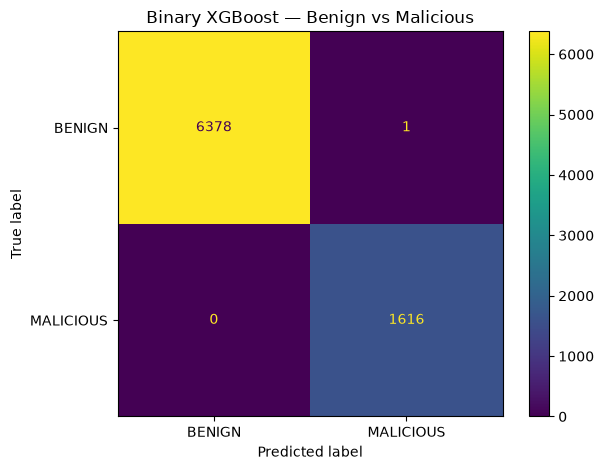


Model saved as: binary_xgboost_classifier.json


In [14]:
# Cell 14 — Binary XGBoost: BENIGN vs MALICIOUS

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import numpy as np


# ==================================================
# 1. Combine benign and malicious data
# ==================================================

X_binary = np.vstack([
    X_benign_scaled,
    X_malicious_scaled
])

# BENIGN = 0
# MALICIOUS = 1

y_binary = np.concatenate([
    np.zeros(len(X_benign_scaled), dtype=int),
    np.ones(len(X_malicious_scaled), dtype=int)
])


print("Total samples:", len(X_binary))
print("Benign samples:", np.sum(y_binary == 0))
print("Malicious samples:", np.sum(y_binary == 1))


# ==================================================
# 2. Train/test split
# ==================================================

X_binary_train, X_binary_test, y_binary_train, y_binary_test = train_test_split(
    X_binary,
    y_binary,
    test_size=0.20,
    random_state=42,
    stratify=y_binary
)


print("\nTraining samples:", len(X_binary_train))
print("Testing samples:", len(X_binary_test))


# ==================================================
# 3. Calculate class imbalance weight
# ==================================================

negative_samples = np.sum(y_binary_train == 0)
positive_samples = np.sum(y_binary_train == 1)

scale_pos_weight = (
    negative_samples / positive_samples
)

print(
    "\nScale positive weight:",
    round(scale_pos_weight, 2)
)


# ==================================================
# 4. Create Binary XGBoost
# ==================================================

binary_xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,

    objective="binary:logistic",

    eval_metric="logloss",

    scale_pos_weight=scale_pos_weight,

    random_state=42
)


# ==================================================
# 5. Train
# ==================================================

binary_xgb_model.fit(
    X_binary_train,
    y_binary_train
)


print("\nBinary XGBoost training complete.")


# ==================================================
# 6. Predictions
# ==================================================

y_binary_pred = binary_xgb_model.predict(
    X_binary_test
)


# ==================================================
# 7. Evaluation metrics
# ==================================================

accuracy = accuracy_score(
    y_binary_test,
    y_binary_pred
)

precision = precision_score(
    y_binary_test,
    y_binary_pred,
    zero_division=0
)

recall = recall_score(
    y_binary_test,
    y_binary_pred,
    zero_division=0
)

f1 = f1_score(
    y_binary_test,
    y_binary_pred,
    zero_division=0
)


print("\n======================================")
print("BINARY XGBOOST RESULTS")
print("======================================")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")


# ==================================================
# 8. Classification report
# ==================================================

print("\n======================================")
print("Classification Report")
print("======================================")

print(
    classification_report(
        y_binary_test,
        y_binary_pred,
        target_names=[
            "BENIGN",
            "MALICIOUS"
        ],
        zero_division=0
    )
)


# ==================================================
# 9. Confusion matrix
# ==================================================

cm_binary = confusion_matrix(
    y_binary_test,
    y_binary_pred
)

print("\n======================================")
print("Confusion Matrix")
print("======================================")

print(cm_binary)


# ==================================================
# 10. Display confusion matrix
# ==================================================

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_binary,
    display_labels=[
        "BENIGN",
        "MALICIOUS"
    ]
)

disp.plot()

plt.title(
    "Binary XGBoost — Benign vs Malicious"
)

plt.tight_layout()
plt.show()


# ==================================================
# 11. Save binary classifier
# ==================================================

binary_xgb_model.save_model(
    "binary_xgboost_classifier.json"
)

print(
    "\nModel saved as:",
    "binary_xgboost_classifier.json"
)

In [15]:
# Cell 15 — Final Multiclass XGBoost Model

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import joblib
import numpy as np

# Encode attack labels
final_label_encoder = LabelEncoder()
y_attack = final_label_encoder.fit_transform(y_malicious)

print("Attack classes:")
for i, label in enumerate(final_label_encoder.classes_):
    print(i, "=", label)

# Train/test split
X_attack_train, X_attack_test, y_attack_train, y_attack_test = train_test_split(
    X_malicious_scaled,
    y_attack,
    test_size=0.20,
    random_state=42,
    stratify=y_attack
)

print("\nTraining samples:", len(X_attack_train))
print("Testing samples:", len(X_attack_test))

# Train final multiclass model
final_multiclass_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42
)

final_multiclass_model.fit(
    X_attack_train,
    y_attack_train
)

# Evaluate
y_attack_pred = final_multiclass_model.predict(X_attack_test)

accuracy = accuracy_score(y_attack_test, y_attack_pred)
precision = precision_score(
    y_attack_test,
    y_attack_pred,
    average="weighted"
)
recall = recall_score(
    y_attack_test,
    y_attack_pred,
    average="weighted"
)
f1 = f1_score(
    y_attack_test,
    y_attack_pred,
    average="weighted"
)

print("\nFinal Multiclass XGBoost Results")
print("--------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_attack_test,
        y_attack_pred,
        target_names=final_label_encoder.classes_
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_attack_test, y_attack_pred))

# Save final model
final_multiclass_model.save_model(
    "xgboost_multiclass_final.json"
)

joblib.dump(
    final_label_encoder,
    "label_encoder_final.pkl"
)

print("\nFinal multiclass model saved.")

Attack classes:
0 = DDoS
1 = FTP-Patator
2 = PortScan
3 = SSH-Patator

Training samples: 6463
Testing samples: 1616

Final Multiclass XGBoost Results
--------------------------------
Accuracy : 0.9988
Precision: 0.9988
Recall   : 0.9988
F1 Score : 0.9988

Classification Report:
              precision    recall  f1-score   support

        DDoS       1.00      1.00      1.00       688
 FTP-Patator       0.98      1.00      0.99        43
    PortScan       1.00      1.00      1.00       853
 SSH-Patator       0.97      1.00      0.98        32

    accuracy                           1.00      1616
   macro avg       0.99      1.00      0.99      1616
weighted avg       1.00      1.00      1.00      1616


Confusion Matrix:
[[688   0   0   0]
 [  0  43   0   0]
 [  0   1 851   1]
 [  0   0   0  32]]

Final multiclass model saved.


In [16]:
# Cell 16 — Full Hybrid Inference Pipeline

import shap
import json
import numpy as np

# ---------------------------------------------------------
# 1. Create SHAP explainer for final multiclass model
# ---------------------------------------------------------

shap_explainer = shap.TreeExplainer(final_multiclass_model)

print("Hybrid inference pipeline initialized.")


# ---------------------------------------------------------
# 2. Hybrid prediction function
# ---------------------------------------------------------

def hybrid_predict(sample):

    # Convert input to 2D numpy array
    sample = np.asarray(sample).reshape(1, -1)

    # -----------------------------------------------------
    # Autoencoder anomaly score
    # -----------------------------------------------------

    reconstructed = autoencoder.predict(
        sample,
        verbose=0
    )

    anomaly_score = float(
        np.mean(
            np.square(sample - reconstructed),
            axis=1
        )[0]
    )

    is_anomaly = anomaly_score > threshold

    # -----------------------------------------------------
    # Binary XGBoost — BENIGN vs MALICIOUS
    # -----------------------------------------------------

    binary_probability = float(
        binary_xgb_model.predict_proba(sample)[0][1]
    )

    is_attack = binary_probability >= 0.5

    # -----------------------------------------------------
    # If benign, stop here
    # -----------------------------------------------------

    if not is_attack:

        return {
            "is_attack": False,
            "attack_type": "BENIGN",
            "attack_confidence": round(
                1 - binary_probability,
                4
            ),
            "malicious_probability": round(
                binary_probability,
                4
            ),
            "anomaly_score": round(
                anomaly_score,
                6
            ),
            "is_anomaly": bool(is_anomaly),
            "top_features": []
        }

    # -----------------------------------------------------
    # Multiclass XGBoost — identify attack type
    # -----------------------------------------------------

    attack_probabilities = (
        final_multiclass_model.predict_proba(sample)[0]
    )

    predicted_class = int(
        np.argmax(attack_probabilities)
    )

    predicted_attack = str(
        final_label_encoder.inverse_transform(
            [predicted_class]
        )[0]
    )

    attack_confidence = float(
        attack_probabilities[predicted_class]
    )

    # -----------------------------------------------------
    # SHAP explanation
    # -----------------------------------------------------

    shap_values = shap_explainer.shap_values(sample)

    shap_array = np.asarray(shap_values)

    if shap_array.ndim == 3:
        sample_shap = shap_array[
            0,
            :,
            predicted_class
        ]

    elif shap_array.ndim == 2:
        sample_shap = shap_array[0]

    else:
        sample_shap = shap_array.flatten()

    # Get top 5 contributing features
    top_indices = np.argsort(
        np.abs(sample_shap)
    )[-5:][::-1]

    top_features = []

    for idx in top_indices:

        top_features.append({
            "feature": str(X.columns[idx]),
            "shap_value": round(
                float(sample_shap[idx]),
                6
            )
        })

    # -----------------------------------------------------
    # Final result
    # -----------------------------------------------------

    result = {
        "is_attack": True,
        "attack_type": predicted_attack,
        "attack_confidence": round(
            attack_confidence,
            4
        ),
        "malicious_probability": round(
            binary_probability,
            4
        ),
        "anomaly_score": round(
            anomaly_score,
            6
        ),
        "is_anomaly": bool(is_anomaly),
        "top_features": top_features
    }

    return result


print("Hybrid prediction function ready.")

Hybrid inference pipeline initialized.
Hybrid prediction function ready.


In [17]:
# Cell 17 — Test Hybrid Pipeline on a Malicious Flow

test_sample = X_malicious_scaled[0]

result = hybrid_predict(test_sample)

print(json.dumps(result, indent=2))

{
  "is_attack": true,
  "attack_type": "DDoS",
  "attack_confidence": 0.9998,
  "malicious_probability": 1.0,
  "anomaly_score": 0.000239,
  "is_anomaly": false,
  "top_features": [
    {
      "feature": "Total Length of Fwd Packets",
      "shap_value": 2.226561
    },
    {
      "feature": "act_data_pkt_fwd",
      "shap_value": 1.322991
    },
    {
      "feature": "Subflow Fwd Bytes",
      "shap_value": 0.253846
    },
    {
      "feature": "Init_Win_bytes_forward",
      "shap_value": 0.227172
    },
    {
      "feature": "Flow IAT Min",
      "shap_value": 0.170035
    }
  ]
}


In [18]:
# Cell 18 — Test Hybrid Pipeline on a Benign Flow

test_benign_sample = X_benign_scaled[0]

benign_result = hybrid_predict(test_benign_sample)

print(json.dumps(benign_result, indent=2))

{
  "is_attack": false,
  "attack_type": "BENIGN",
  "attack_confidence": 1.0,
  "malicious_probability": 0.0,
  "anomaly_score": 4.5e-05,
  "is_anomaly": false,
  "top_features": []
}


In [19]:
# Cell 19 — Live Traffic Simulator

import time
import json
import random
from datetime import datetime

# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------

NUM_FLOWS = 20
DELAY_SECONDS = 0.5

print("Starting live traffic simulation...")
print(f"Simulating {NUM_FLOWS} network flows")
print("-" * 70)


# ---------------------------------------------------------
# Prepare a mixed pool of benign and malicious flows
# ---------------------------------------------------------

benign_indices = random.sample(
    range(len(X_benign_scaled)),
    min(NUM_FLOWS // 2, len(X_benign_scaled))
)

malicious_indices = random.sample(
    range(len(X_malicious_scaled)),
    min(NUM_FLOWS - len(benign_indices), len(X_malicious_scaled))
)


# Create labeled simulation pool
traffic_pool = []

for idx in benign_indices:
    traffic_pool.append({
        "features": X_benign_scaled[idx],
        "true_label": "BENIGN"
    })

for idx in malicious_indices:
    traffic_pool.append({
        "features": X_malicious_scaled[idx],
        "true_label": str(y_malicious.iloc[idx])
    })


# Shuffle traffic to simulate mixed live traffic
random.shuffle(traffic_pool)


# ---------------------------------------------------------
# Process flows one by one
# ---------------------------------------------------------

simulation_results = []

for flow_number, flow in enumerate(traffic_pool, start=1):

    # Run hybrid ML inference
    result = hybrid_predict(flow["features"])

    # Add streaming metadata
    result["flow_id"] = flow_number
    result["timestamp"] = datetime.now().isoformat()
    result["true_label"] = flow["true_label"]

    # Store result
    simulation_results.append(result)

    # Display event
    print(f"\nFlow #{flow_number}")
    print(f"Timestamp: {result['timestamp']}")
    print(f"True label: {result['true_label']}")
    print(f"Prediction: {result['attack_type']}")
    print(f"Attack: {result['is_attack']}")
    print(f"Confidence: {result['attack_confidence']}")
    print(f"Anomaly score: {result['anomaly_score']}")

    if result["is_attack"]:
        print("🚨 ATTACK DETECTED")
    else:
        print("✓ BENIGN")

    print("-" * 70)

    # Simulate time between incoming flows
    time.sleep(DELAY_SECONDS)


print("\nSimulation complete.")
print(f"Processed flows: {len(simulation_results)}")

Starting live traffic simulation...
Simulating 20 network flows
----------------------------------------------------------------------

Flow #1
Timestamp: 2026-09-11T08:25:27.773721
True label: PortScan
Prediction: PortScan
Attack: True
Confidence: 0.9999
Anomaly score: 0.002777
🚨 ATTACK DETECTED
----------------------------------------------------------------------

Flow #2
Timestamp: 2026-09-11T08:25:28.340620
True label: PortScan
Prediction: PortScan
Attack: True
Confidence: 0.9999
Anomaly score: 0.000118
🚨 ATTACK DETECTED
----------------------------------------------------------------------

Flow #3
Timestamp: 2026-09-11T08:25:28.920508
True label: DDoS
Prediction: DDoS
Attack: True
Confidence: 0.9998
Anomaly score: 0.033908
🚨 ATTACK DETECTED
----------------------------------------------------------------------

Flow #4
Timestamp: 2026-09-11T08:25:29.509376
True label: BENIGN
Prediction: BENIGN
Attack: False
Confidence: 1.0
Anomaly score: 8.2e-05
✓ BENIGN
------------------------

In [20]:
# Cell 20 — Live Traffic Simulation Summary

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ---------------------------------------------------------
# Extract true and predicted labels
# ---------------------------------------------------------

true_labels = [
    result["true_label"]
    for result in simulation_results
]

predicted_labels = [
    result["attack_type"]
    for result in simulation_results
]

# ---------------------------------------------------------
# Overall accuracy
# ---------------------------------------------------------

overall_accuracy = accuracy_score(
    true_labels,
    predicted_labels
)

print("LIVE TRAFFIC SIMULATION SUMMARY")
print("=" * 60)

print(f"Total flows processed : {len(simulation_results)}")
print(f"Benign flows          : {true_labels.count('BENIGN')}")
print(
    f"Malicious flows       : "
    f"{len(true_labels) - true_labels.count('BENIGN')}"
)

print(f"\nOverall accuracy      : {overall_accuracy:.4f}")

# ---------------------------------------------------------
# Attack detection statistics
# ---------------------------------------------------------

actual_attacks = sum(
    label != "BENIGN"
    for label in true_labels
)

detected_attacks = sum(
    result["is_attack"]
    for result in simulation_results
)

correct_attack_types = sum(
    result["is_attack"] and
    result["true_label"] == result["attack_type"]
    for result in simulation_results
)

print(f"Actual attacks        : {actual_attacks}")
print(f"Attacks detected      : {detected_attacks}")
print(f"Correct attack types  : {correct_attack_types}")

if actual_attacks > 0:
    detection_rate = detected_attacks / actual_attacks
    print(f"Attack detection rate : {detection_rate:.4f}")

# ---------------------------------------------------------
# Anomaly statistics
# ---------------------------------------------------------

anomaly_count = sum(
    result["is_anomaly"]
    for result in simulation_results
)

print(f"\nAnomalies flagged      : {anomaly_count}")

# ---------------------------------------------------------
# Classification report
# ---------------------------------------------------------

print("\nClassification Report:")
print(
    classification_report(
        true_labels,
        predicted_labels,
        zero_division=0
    )
)

# ---------------------------------------------------------
# Confusion matrix
# ---------------------------------------------------------

labels = [
    "BENIGN",
    "DDoS",
    "FTP-Patator",
    "PortScan",
    "SSH-Patator"
]

cm = confusion_matrix(
    true_labels,
    predicted_labels,
    labels=labels
)

print("\nConfusion Matrix:")
print("Labels:", labels)
print(cm)

print("\nSimulation evaluation complete.")

LIVE TRAFFIC SIMULATION SUMMARY
Total flows processed : 20
Benign flows          : 10
Malicious flows       : 10

Overall accuracy      : 1.0000
Actual attacks        : 10
Attacks detected      : 10
Correct attack types  : 10
Attack detection rate : 1.0000

Anomalies flagged      : 1

Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00        10
        DDoS       1.00      1.00      1.00         3
    PortScan       1.00      1.00      1.00         7

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20


Confusion Matrix:
Labels: ['BENIGN', 'DDoS', 'FTP-Patator', 'PortScan', 'SSH-Patator']
[[10  0  0  0  0]
 [ 0  3  0  0  0]
 [ 0  0  0  0  0]
 [ 0  0  0  7  0]
 [ 0  0  0  0  0]]

Simulation evaluation complete.


In [21]:
# Cell 21 — Generate Security Events

import json
from datetime import datetime

security_events = []

for result in simulation_results:

    # Determine severity
    if result["is_attack"]:

        if result["attack_type"] == "DDoS":
            severity = "Critical"

        elif result["attack_type"] == "PortScan":
            severity = "High"

        else:
            severity = "High"

    elif result["is_anomaly"]:

        severity = "Medium"

    else:

        severity = "Low"

    # Create standardized security event
    event = {
        "timestamp": result["timestamp"],
        "flow_id": result["flow_id"],
        "is_attack": result["is_attack"],
        "attack_type": result["attack_type"],
        "attack_confidence": result["attack_confidence"],
        "malicious_probability": result["malicious_probability"],
        "anomaly_score": result["anomaly_score"],
        "is_anomaly": result["is_anomaly"],
        "severity": severity,
        "top_features": result["top_features"]
    }

    security_events.append(event)


# ---------------------------------------------------------
# Display first few events
# ---------------------------------------------------------

print("Security events generated:", len(security_events))
print("\nExample security event:")
print(json.dumps(security_events[0], indent=2))

print("\n" + "=" * 70)

print("All security events:")
for event in security_events:
    print(
        f"{event['timestamp']} | "
        f"{event['attack_type']:12} | "
        f"{event['severity']:8} | "
        f"confidence={event['attack_confidence']}"
    )

Security events generated: 20

Example security event:
{
  "timestamp": "2026-09-11T08:25:27.773721",
  "flow_id": 1,
  "is_attack": true,
  "attack_type": "PortScan",
  "attack_confidence": 0.9999,
  "malicious_probability": 1.0,
  "anomaly_score": 0.002777,
  "is_anomaly": false,
  "severity": "High",
  "top_features": [
    {
      "feature": "Bwd Packet Length Min",
      "shap_value": 2.780115
    },
    {
      "feature": "Total Length of Fwd Packets",
      "shap_value": 0.85517
    },
    {
      "feature": "act_data_pkt_fwd",
      "shap_value": 0.516001
    },
    {
      "feature": "Destination Port",
      "shap_value": 0.320345
    },
    {
      "feature": "Flow Bytes/s",
      "shap_value": 0.263012
    }
  ]
}

All security events:
2026-09-11T08:25:27.773721 | PortScan     | High     | confidence=0.9999
2026-09-11T08:25:28.340620 | PortScan     | High     | confidence=0.9999
2026-09-11T08:25:28.920508 | DDoS         | Critical | confidence=0.9998
2026-09-11T08:25:29.509

In [22]:
# Cell 22 — Export Security Events as JSON Lines

import json
import os

EVENT_FILE = "security_events.jsonl"

with open(EVENT_FILE, "w", encoding="utf-8") as f:

    for event in security_events:
        f.write(
            json.dumps(event)
            + "\n"
        )

print("Security event stream created.")
print("File:", os.path.abspath(EVENT_FILE))
print("Events written:", len(security_events))

# ---------------------------------------------------------
# Preview first 3 events
# ---------------------------------------------------------

print("\nPreview:")
print("-" * 70)

with open(EVENT_FILE, "r", encoding="utf-8") as f:

    for i, line in enumerate(f):

        if i >= 3:
            break

        print(json.dumps(
            json.loads(line),
            indent=2
        ))

        print("-" * 70)

Security event stream created.
File: c:\Users\Khatija\Desktop\CIC_IDS_PROJECT\notebooks\security_events.jsonl
Events written: 20

Preview:
----------------------------------------------------------------------
{
  "timestamp": "2026-09-11T08:25:27.773721",
  "flow_id": 1,
  "is_attack": true,
  "attack_type": "PortScan",
  "attack_confidence": 0.9999,
  "malicious_probability": 1.0,
  "anomaly_score": 0.002777,
  "is_anomaly": false,
  "severity": "High",
  "top_features": [
    {
      "feature": "Bwd Packet Length Min",
      "shap_value": 2.780115
    },
    {
      "feature": "Total Length of Fwd Packets",
      "shap_value": 0.85517
    },
    {
      "feature": "act_data_pkt_fwd",
      "shap_value": 0.516001
    },
    {
      "feature": "Destination Port",
      "shap_value": 0.320345
    },
    {
      "feature": "Flow Bytes/s",
      "shap_value": 0.263012
    }
  ]
}
----------------------------------------------------------------------
{
  "timestamp": "2026-09-11T08:25:28.

In [31]:
import sys
sys.path.append('../streaming')  # adjust path to wherever streaming/ actually sits relative to your notebook
from kafka_producer import publish_events

publish_events(security_events, delay_seconds=1)

Connected to Kafka at localhost:9092
Publishing to topic: network-events
----------------------------------------------------------------------
Sent event 1/20 | PortScan     | High
Sent event 2/20 | PortScan     | High
Sent event 3/20 | DDoS         | Critical
Sent event 4/20 | BENIGN       | Low
Sent event 5/20 | PortScan     | High
Sent event 6/20 | PortScan     | High
Sent event 7/20 | BENIGN       | Low
Sent event 8/20 | DDoS         | Critical
Sent event 9/20 | BENIGN       | Low
Sent event 10/20 | PortScan     | High
Sent event 11/20 | BENIGN       | Low
Sent event 12/20 | DDoS         | Critical
Sent event 13/20 | BENIGN       | Low
Sent event 14/20 | BENIGN       | Low
Sent event 15/20 | BENIGN       | Low
Sent event 16/20 | PortScan     | High
Sent event 17/20 | BENIGN       | Low
Sent event 18/20 | BENIGN       | Low
Sent event 19/20 | PortScan     | High
Sent event 20/20 | BENIGN       | Low

All security events sent successfully.


In [24]:
   import sys
   print(sys.executable)

c:\Users\Khatija\Desktop\CIC_IDS_PROJECT\.venv\Scripts\python.exe


In [25]:
import sys
!{sys.executable} -m pip install kafka-python psycopg2-binary

In [26]:
print(security_events[0])

{'timestamp': '2026-09-11T08:25:27.773721', 'flow_id': 1, 'is_attack': True, 'attack_type': 'PortScan', 'attack_confidence': 0.9999, 'malicious_probability': 1.0, 'anomaly_score': 0.002777, 'is_anomaly': False, 'severity': 'High', 'top_features': [{'feature': 'Bwd Packet Length Min', 'shap_value': 2.780115}, {'feature': 'Total Length of Fwd Packets', 'shap_value': 0.85517}, {'feature': 'act_data_pkt_fwd', 'shap_value': 0.516001}, {'feature': 'Destination Port', 'shap_value': 0.320345}, {'feature': 'Flow Bytes/s', 'shap_value': 0.263012}]}


## Saved artifacts
- `autoencoder_model.h5`
- `xgboost_classifier.json`
- `scaler.pkl`
- `label_encoder.pkl`

These four files are what your Phase 4 inference script (Event Hubs → Stream Analytics → this pipeline → Sentinel) will load to score live/simulated traffic without retraining.